# Pears 3

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
from hmmlearn import hmm

In [111]:
def create_volume_bars(ask_file, bid_file, vol_threshold=1000):
    """Helper function to convert raw Bid/Ask parquets into Volume Bars."""
    
    # Load and sort
    df_ask = pd.read_parquet(ask_file).sort_values('datetime')
    df_bid = pd.read_parquet(bid_file).sort_values('datetime')
    
    # Rename columns
    df_ask = df_ask.rename(columns={'price': 'ask_price', 'volume': 'ask_volume'})
    df_bid = df_bid.rename(columns={'price': 'bid_price', 'volume': 'bid_volume'})

    # ==========================================
    # EXACT PLACEMENT: CLIP THE DATA HERE
    # ==========================================
    # Clip Weekends (Keep Mon-Fri, where Monday=0 and Friday=4)
    df_ask = df_ask[df_ask['datetime'].dt.dayofweek < 5]
    df_bid = df_bid[df_bid['datetime'].dt.dayofweek < 5]
    
    # Clip Off-Hours (Keep 07:00 to 16:00 UTC)
    df_ask = df_ask[(df_ask['datetime'].dt.hour >= 7) & (df_ask['datetime'].dt.hour <= 16)]
    df_bid = df_bid[(df_bid['datetime'].dt.hour >= 7) & (df_bid['datetime'].dt.hour <= 16)]
    
    # --- ADD THIS DIAGNOSTIC PRINTOUT ---
    min_hour = df_ask['datetime'].dt.hour.min()
    max_hour = df_ask['datetime'].dt.hour.max()
    active_days = df_ask['datetime'].dt.day_name().unique().tolist()
    
    print(f"Filter Check -> Active Hours: {min_hour}:00 to {max_hour}:00 UTC")
    print(f"Filter Check -> Active Days: {active_days}")
    # ==========================================
    
    # Asynchronous merge
    df_ticks = pd.merge_asof(
        df_ask[['datetime', 'ask_price', 'ask_volume']],
        df_bid[['datetime', 'bid_price', 'bid_volume']],
        on='datetime',
        direction='backward'
    ).dropna()
    
    # Calculations
    df_ticks['mid_price'] = (df_ticks['bid_price'] + df_ticks['ask_price']) / 2
    df_ticks['total_volume'] = df_ticks['bid_volume'] + df_ticks['ask_volume']
    df_ticks['cum_vol'] = df_ticks['total_volume'].cumsum()
    
    # Bar Generation
    df_ticks['bar_id'] = (df_ticks['cum_vol'] // vol_threshold).astype(int)
    
    bars = df_ticks.groupby('bar_id').agg(
        timestamp=('datetime', 'last'),
        open=('mid_price', 'first'),
        high=('mid_price', 'max'),
        low=('mid_price', 'min'),
        close=('mid_price', 'last'),
        volume=('total_volume', 'sum')
    ).set_index('timestamp')
    
    return bars


In [112]:
def prepare_pairs_dataframe(ask_A, bid_A, ask_B, bid_B, vol_threshold=1000):
    """Main pipeline: Processes two assets and aligns them into one DataFrame."""
    print("Processing Asset A...")
    bars_A = create_volume_bars(ask_A, bid_A, vol_threshold)
    
    print("Processing Asset B...")
    bars_B = create_volume_bars(ask_B, bid_B, vol_threshold)
    
    print("Aligning timelines...")
    # Align Asset B's prices to Asset A's volume bar timeline
    df_pairs = pd.merge_asof(
        bars_A[['close']].rename(columns={'close': 'Asset_A'}),
        bars_B[['close']].rename(columns={'close': 'Asset_B'}),
        left_index=True,
        right_index=True,
        direction='backward'
    ).dropna()
    
    print(f"Success! Final aligned pairs dataset has {len(df_pairs)} rows.")
    return df_pairs

In [113]:
file_a_ask = "../data/processed/eurnok_dukascopy_ask_202601.parquet"
file_a_bid = "../data/processed/eurnok_dukascopy_bid_202601.parquet"

file_b_ask = "../data/processed/eursek_dukascopy_ask_202601.parquet"
file_b_bid = "../data/processed/eursek_dukascopy_bid_202601.parquet"

# Generate the master dataframe
df_pairs = prepare_pairs_dataframe(file_a_ask, file_a_bid, file_b_ask, file_b_bid, vol_threshold=1000)

print(df_pairs.head(3))

Processing Asset A...


Filter Check -> Active Hours: 7:00 to 16:00 UTC
Filter Check -> Active Days: ['Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Processing Asset B...
Filter Check -> Active Hours: 7:00 to 16:00 UTC
Filter Check -> Active Days: ['Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Aligning timelines...
Success! Final aligned pairs dataset has 2974 rows.
                                    Asset_A    Asset_B
timestamp                                             
2026-01-02 07:09:46.836000+00:00  11.821590  10.814695
2026-01-02 07:19:10.697000+00:00  11.828795  10.820155
2026-01-02 07:25:52.182000+00:00  11.834140  10.820155


In [114]:
def calculate_dynamic_spread(df, window=100):
    """Calculates a rolling hedge ratio and extracts the stationary spread."""
    print(f"Calculating Rolling Beta (Window: {window} bars)...")
    
    # We predict Asset A using Asset B. Add a constant for the intercept.
    exog = sm.add_constant(df['Asset_B'])
    rols = RollingOLS(df['Asset_A'], exog, window=window)
    rolling_res = rols.fit()
    
    # Extract the beta (the coefficient for Asset_B)
    df['beta'] = rolling_res.params['Asset_B']
    
    # Calculate the Spread: A - (Beta * B)
    df['spread'] = df['Asset_A'] - (df['beta'] * df['Asset_B'])
    
    # Drop the initial NaN rows where the 100-bar window was filling up
    df_clean = df.dropna()
    
    print(f"Success! Spread calculated. {len(df_clean)} rows ready for modeling.")
    return df_clean

In [115]:
df_clean = calculate_dynamic_spread(df_pairs, window=100)

print(df_clean[['Asset_A', 'Asset_B', 'beta', 'spread']].head(3))

Calculating Rolling Beta (Window: 100 bars)...
Success! Spread calculated. 2875 rows ready for modeling.
                                   Asset_A    Asset_B      beta    spread
timestamp                                                                
2026-01-02 15:59:43.033000+00:00  11.80323  10.806600  1.192500 -1.083640
2026-01-02 16:01:48.155000+00:00  11.80287  10.807370  1.187129 -1.026877
2026-01-02 16:03:57.985000+00:00  11.80665  10.808315  1.167228 -0.809113


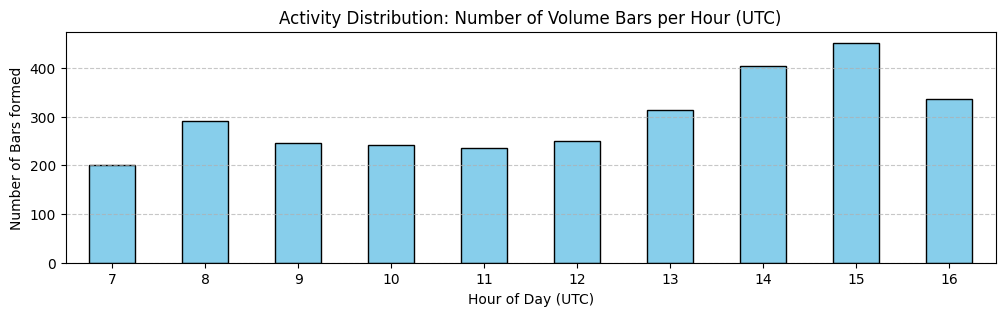

Total bars in dataset: 2974
Peak activity hour: 15:00 UTC with 452 bars.


In [116]:
# ==========================================
# VALIDATING THE LIMITS (Using Bar Counts)
# ==========================================
# Since 1 bar = 1000 volume, the number of bars per hour IS the volume distribution
df_pairs_plot = df_pairs.copy()
df_pairs_plot['hour'] = df_pairs_plot.index.hour

# Count how many bars were formed in each hour
bars_per_hour = df_pairs_plot.groupby('hour').size()

plt.figure(figsize=(12, 3))
bars_per_hour.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Activity Distribution: Number of Volume Bars per Hour (UTC)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Number of Bars formed")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print a quick summary to see if 07:00-16:00 is indeed the "meat"
print(f"Total bars in dataset: {len(df_pairs)}")
print(f"Peak activity hour: {bars_per_hour.idxmax()}:00 UTC with {bars_per_hour.max()} bars.")

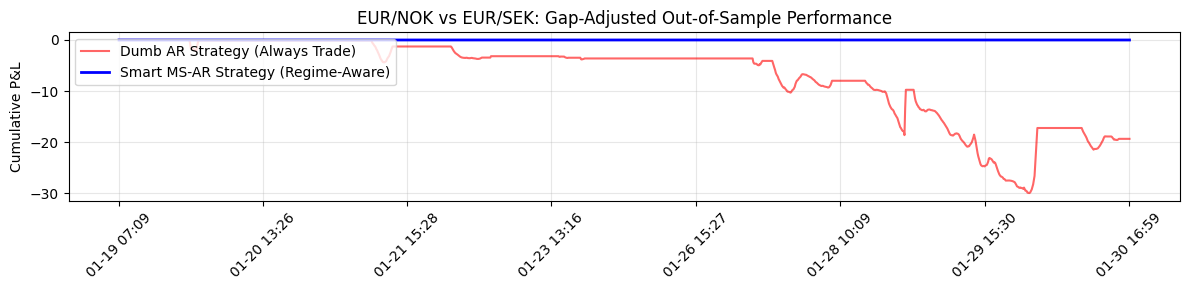

In [117]:
# ==========================================
# 4. PLOT THE REAL-WORLD EQUITY CURVE (FIXED)
# ==========================================
cumulative_ar = np.cumsum(ar_pnl)
cumulative_msar = np.cumsum(msar_pnl)

plt.figure(figsize=(12, 3))

# USE A SEQUENTIAL INDEX: This removes the straight lines over weekends/nights
x_axis = np.arange(len(cumulative_ar))

plt.plot(x_axis, cumulative_ar, label='Dumb AR Strategy (Always Trade)', color='red', alpha=0.6)
plt.plot(x_axis, cumulative_msar, label='Smart MS-AR Strategy (Regime-Aware)', color='blue', linewidth=2)

# FIX THE X-AXIS LABELS: Map the sequential numbers back to actual timestamps
# We pick 8 evenly spaced points to show on the axis
tick_indices = np.linspace(0, len(x_axis)-1, 8, dtype=int)
# We use the full test_data index here
tick_labels = test_data.index[tick_indices].strftime('%m-%d %H:%M')
plt.xticks(tick_indices, tick_labels, rotation=45)

plt.title("EUR/NOK vs EUR/SEK: Gap-Adjusted Out-of-Sample Performance")
plt.ylabel("Cumulative P&L")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\ofurn\AppData\Local\Temp\ipykernel_4488\3712236222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['hour'] = df_clean.index.hour


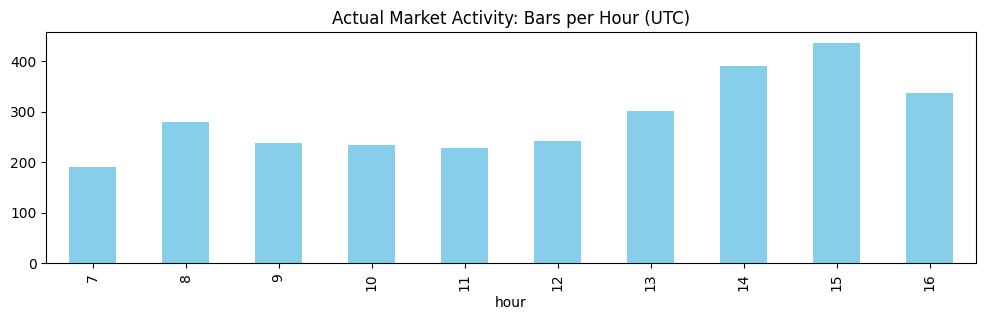

In [118]:
# Check which hours actually produce the most volume bars
df_clean['hour'] = df_clean.index.hour
bar_counts = df_clean.groupby('hour').size()

plt.figure(figsize=(12, 3))
bar_counts.plot(kind='bar', color='skyblue')
plt.title("Actual Market Activity: Bars per Hour (UTC)")
plt.show()

In [121]:
# ==========================================
# 1. TIGHTEN THE HMM (3 States)
# ==========================================
X_train = train_df[['spread', 'rolling_vol']].values
# 3 States: 0=Quiet, 1=Noisy, 2=Chaos
hmm_model = hmm.GaussianHMM(n_components=3, covariance_type="full", random_state=42)
hmm_model.fit(X_train)

# Identify the "Quiet" state (lowest mean volatility)
vols = [hmm_model.means_[i][1] for i in range(3)]
quiet_state = np.argmin(vols)
chaos_state = np.argmax(vols)

print(f"HMM calibrated. Quiet State: {quiet_state} (Mean Vol: {vols[quiet_state]:.4f})")

# ==========================================
# 2. TRADE UNTIL MEAN-CROSS (Not just 1 bar)
# ==========================================
msar_pnl = []
position = 0 # 0=None, 1=Long Spread, -1=Short Spread
entry_price = 0

for t in range(len(test_df) - 1):
    curr_spread = test_df['spread'].iloc[t]
    next_spread = test_df['spread'].iloc[t+1]
    regime = hmm_model.predict(test_df[['spread', 'rolling_vol']].iloc[t:t+1].values)[0]
    
    # EXIT LOGIC: Close position if we cross the mean
    if position != 0:
        if (position == 1 and curr_spread >= spread_mean) or \
           (position == -1 and curr_spread <= spread_mean):
            # Trade complete!
            position = 0
            
    # ENTRY LOGIC: Only if we are in the 'Quiet' state
    if position == 0 and regime == quiet_state:
        if curr_spread > (spread_mean + entry_val):
            position = -1 # Short the spread
            entry_price = curr_spread
        elif curr_spread < (spread_mean - entry_val):
            position = 1 # Long the spread
            entry_price = curr_spread

    # RECORD PNL (If in a position, we gain/lose based on movement)
    if position == 1:
        msar_pnl.append((next_spread - curr_spread) - (COST if entry_price == curr_spread else 0))
    elif position == -1:
        msar_pnl.append((curr_spread - next_spread) - (COST if entry_price == curr_spread else 0))
    else:
        msar_pnl.append(0)

# ==========================================
# 3. COMPARE THE RESULTS
# ==========================================
msar_trades = np.array([x for x in msar_pnl if x != 0])
if len(msar_trades) > 0:
    win_rate = (len(msar_trades[msar_trades > 0]) / len(msar_trades)) * 100
    print(f"\n--- SMART MS-AR (PRO EXIT) ---")
    print(f"Total Trade Bars: {len(msar_trades)}")
    print(f"Cumulative P&L: {np.sum(msar_trades):.2f}")
    print(f"Win Rate per Tick: {win_rate:.1f}%")

HMM calibrated. Quiet State: 2 (Mean Vol: 0.7343)

--- SMART MS-AR (PRO EXIT) ---
Total Trade Bars: 118
Cumulative P&L: 29.14
Win Rate per Tick: 51.7%


In [ ]:
# trackers
msar_pnl = []
ar_pnl = []
pos_msar = 0 # 0, 1, -1
pos_ar = 0   # 0, 1, -1

for t in range(len(test_df) - 1):
    curr_spread = test_df['spread'].iloc[t]
    next_spread = test_df['spread'].iloc[t+1]
    regime = hmm_model.predict(test_df[['spread', 'rolling_vol']].iloc[t:t+1].values)[0]
    
    # --- DUMB AR LOGIC (No Regime Filter) ---
    if pos_ar != 0:
        if (pos_ar == 1 and curr_spread >= spread_mean) or (pos_ar == -1 and curr_spread <= spread_mean):
            pos_ar = 0
    if pos_ar == 0:
        if curr_spread > (spread_mean + entry_val): pos_ar = -1
        elif curr_spread < (spread_mean - entry_val): pos_ar = 1
    
    # --- SMART MS-AR LOGIC (With Quiet State Filter) ---
    if pos_msar != 0:
        if (pos_msar == 1 and curr_spread >= spread_mean) or (pos_msar == -1 and curr_spread <= spread_mean):
            pos_msar = 0
    if pos_msar == 0 and regime == quiet_state:
        if curr_spread > (spread_mean + entry_val): pos_msar = -1
        elif curr_spread < (spread_mean - entry_val): pos_msar = 1

    # --- Record PnL ---
    # Smart
    if pos_msar == 1: msar_pnl.append((next_spread - curr_spread) - (COST if pos_msar != 0 else 0))
    elif pos_msar == -1: msar_pnl.append((curr_spread - next_spread) - (COST if pos_msar != 0 else 0))
    else: msar_pnl.append(0)
    # Dumb
    if pos_ar == 1: ar_pnl.append((next_spread - curr_spread) - (COST if pos_ar != 0 else 0))
    elif pos_ar == -1: ar_pnl.append((curr_spread - next_spread) - (COST if pos_ar != 0 else 0))
    else: ar_pnl.append(0)

In [ ]:
# Calculate Cumulative & Drawdown
cum_ar = np.cumsum(ar_pnl)
cum_msar = np.cumsum(msar_pnl)

def get_drawdown(cum_pnl):
    running_max = np.maximum.accumulate(cum_pnl)
    # Ensure it doesn't stay at 0 if the max is 0
    running_max[running_max < 0] = 0 
    return cum_pnl - running_max

dd_ar = get_drawdown(cum_ar)
dd_msar = get_drawdown(cum_msar)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
x_seq = np.arange(len(cum_ar))

# Panel 1: Equity Curve
ax1.plot(x_seq, cum_ar, label='Dumb AR (Hold-to-Mean)', color='red', alpha=0.5)
ax1.plot(x_seq, cum_msar, label='Smart MS-AR (HMM Filtered)', color='blue', linewidth=2)
ax1.set_title("Strategy Development: Real EUR/NOK vs EUR/SEK", fontsize=14)
ax1.set_ylabel("Cumulative P&L")
ax1.legend()
ax1.grid(True, alpha=0.2)

# Panel 2: Drawdown (Underwater Plot)
ax2.fill_between(x_seq, dd_ar, 0, color='red', alpha=0.2, label='Dumb DD')
ax2.fill_between(x_seq, dd_msar, 0, color='blue', alpha=0.4, label='Smart DD')
ax2.set_title("Underwater Drawdown Profile", fontsize=12)
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Volume Bar Sequence")
ax2.legend()
ax2.grid(True, alpha=0.2)

# Format X-ticks
tick_indices = np.linspace(0, len(x_seq)-1, 10, dtype=int)
plt.xticks(tick_indices, test_df.index[tick_indices].strftime('%m-%d %H:%M'), rotation=30)

plt.tight_layout()
plt.show()